In [16]:
import joblib 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pick which model to explain — comment out the others
#TAG = "augmented"
#TAG = "freegen_qwen"
#TAG = "freegen_llama"
#TAG = "rewrite_qwen"
TAG = "rewrite_llama"

b = joblib.load(f"xgb_bundle_{TAG}.joblib")
clf, tfidf         = b["clf"], b["tfidf"]
feat_names, hand_names = b["feat_names"], b["hand_names"]
Xte, te_x, te_y    = b["Xte"], b["te_x"], np.array(b["te_y"])
hte, htr, tr_y     = b["hte"], b["htr"], np.array(b["tr_y"])
prob, pred         = np.array(b["prob"]), np.array(b["pred"])
print(f"Loaded {TAG}: {Xte.shape[0]} test notes, {len(feat_names)} features")

Loaded rewrite_llama: 400 test notes, 513 features


# Q2: How does the classifier respond across a feature's range? (PDP + ICE)

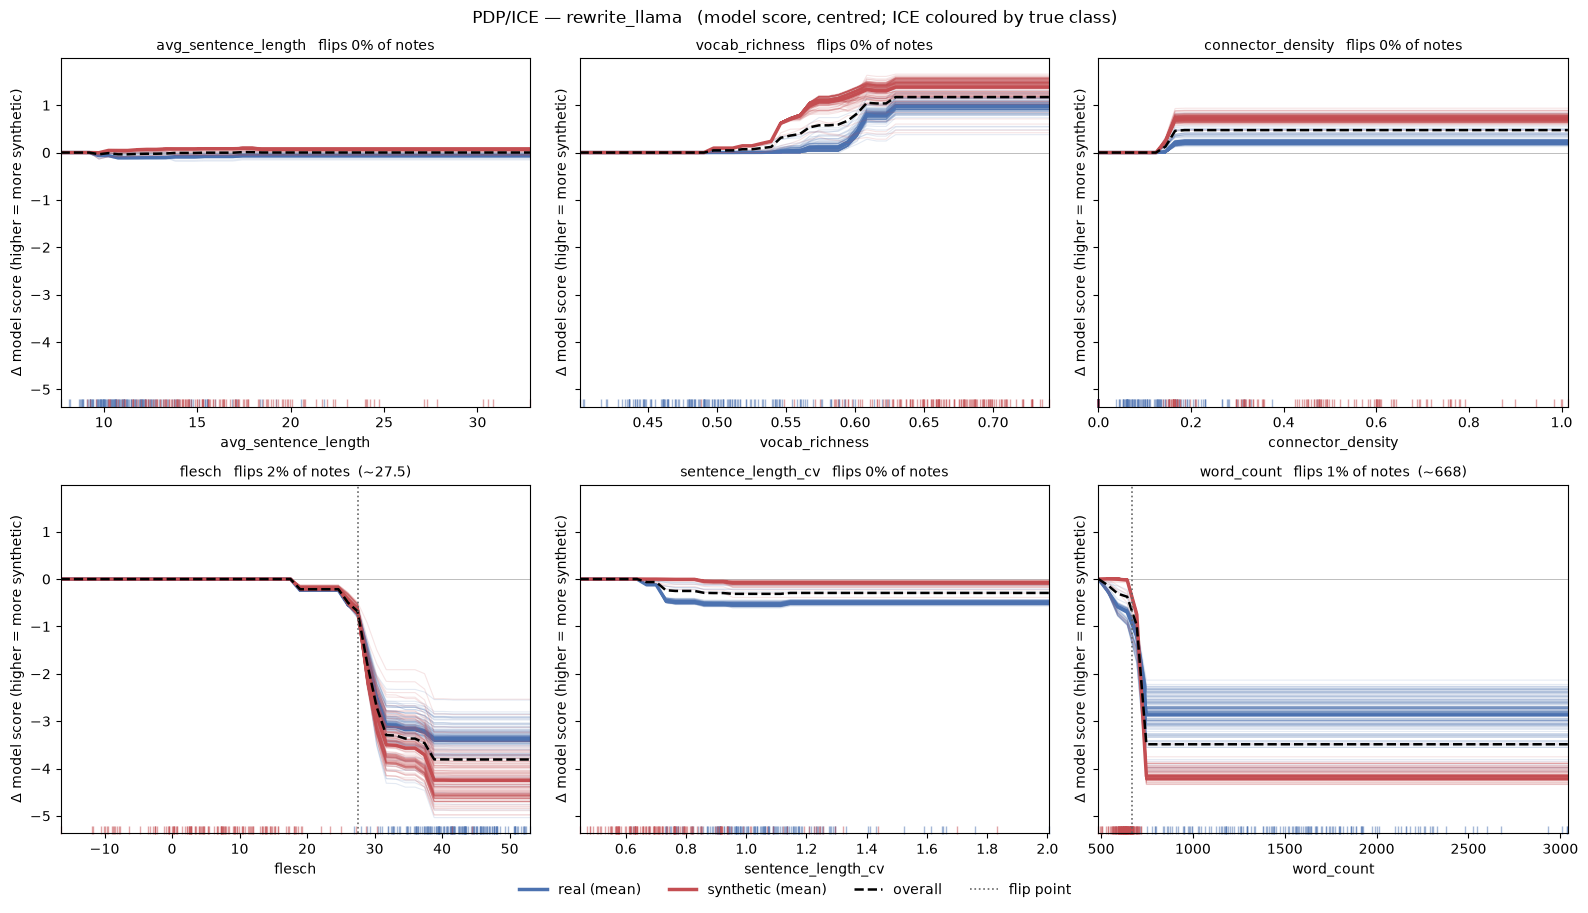

feature                  flips  threshold
flesch                    1.7%  27.5
word_count                1.3%  668
avg_sentence_length       0.0%  —
vocab_richness            0.0%  —
connector_density         0.0%  —
sentence_length_cv        0.0%  —


In [17]:
from matplotlib.lines import Line2D
from xgboost import XGBClassifier

# PDP needs interpretable inputs → model on hand-crafted features only
clf_hand = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.5, reg_alpha=1.0, reg_lambda=2.0,
    eval_metric="logloss", random_state=42).fit(htr.values, tr_y)

# plot the features most likely to carry signal (skip any not present)
wanted = ["avg_sentence_length","vocab_richness","connector_density",
          "flesch","sentence_length_cv","word_count"]
feats = [f for f in wanted if f in hand_names]

X, y = htr.values, np.asarray(tr_y).astype(int)

rng = np.random.default_rng(42)                       # subsample for legibility
sub = rng.choice(len(X), size=min(300, len(X)), replace=False)
Xs, ys = X[sub], y[sub]

COL = {0: "#4C72B0", 1: "#C44E52"}   # real, synthetic
LBL = {0: "real", 1: "synthetic"}


def ice_curves(model, Xs, j, n_grid=50, q=(0.01, 0.99)):
    """Sweep feature j. Returns the model score (for plotting) and the
    probability (for the flip count) on the same grid."""
    lo, hi = np.quantile(Xs[:, j], q)
    if lo == hi:                                      # degenerate / constant feature
        lo, hi = Xs[:, j].min(), Xs[:, j].max()
    grid  = np.linspace(lo, hi, n_grid)
    score = np.empty((len(Xs), n_grid))
    prob  = np.empty((len(Xs), n_grid))
    for k, v in enumerate(grid):
        Xm = Xs.copy(); Xm[:, j] = v
        score[:, k] = model.predict(Xm, output_margin=True)
        prob[:,  k] = model.predict_proba(Xm)[:, 1]
    return grid, score, prob


fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.ravel()
rows = []

for ax, f in zip(axes, feats):
    j = hand_names.index(f)
    grid, score, prob = ice_curves(clf_hand, Xs, j)
    score = score - score[:, [0]]                     # centre each curve at the left edge

    for c in (0, 1):
        m = ys == c
        if not m.any():
            continue
        ax.plot(grid, score[m].T, color=COL[c], alpha=0.15, lw=0.8)   # individual notes
        ax.plot(grid, score[m].mean(0), color=COL[c], lw=2.5)         # class mean
    ax.plot(grid, score.mean(0), color="k", ls="--", lw=1.8)          # overall

    ax.set_xlim(grid.min(), grid.max())
    ax.axhline(0, color="0.7", lw=0.6, zorder=0)

    trans = ax.get_xaxis_transform()                  # rug pinned to bottom of axes
    for c in (0, 1):
        m = ys == c
        v = Xs[m, j]
        v = v[(v >= grid.min()) & (v <= grid.max())]
        ax.plot(v, np.full(len(v), 0.01), '|', color=COL[c], ms=6,
                alpha=0.5, transform=trans, clip_on=False)

    # how many notes change predicted label as this feature is swept, and where
    crosses = (prob.max(1) > 0.5) & (prob.min(1) < 0.5)
    pct = 100 * crosses.mean()
    if crosses.any():
        k   = [np.argmax(np.abs(np.diff((r > 0.5).astype(int)))) for r in prob[crosses]]
        thr = float(np.median(grid[k]))
        ax.axvline(thr, color="0.4", ls=":", lw=1.2)
        ax.set_title(f"{f}   flips {pct:.0f}% of notes  (~{thr:.3g})", fontsize=10)
        rows.append((f, pct, f"{thr:.3g}"))
    else:
        ax.set_title(f"{f}   flips {pct:.0f}% of notes", fontsize=10)
        rows.append((f, pct, "—"))

    ax.set_xlabel(f)
    ax.set_ylabel("Δ model score (higher = more synthetic)")

for ax in axes[len(feats):]:                          # hide unused panels
    ax.set_visible(False)

handles  = [Line2D([], [], color=COL[c], lw=2.5, label=f"{LBL[c]} (mean)") for c in (0, 1)]
handles += [Line2D([], [], color="k",   ls="--", lw=1.8, label="overall"),
            Line2D([], [], color="0.4", ls=":",  lw=1.2, label="flip point")]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"PDP/ICE — {TAG}   (model score, centred; ICE coloured by true class)")
fig.tight_layout()
fig.savefig(f"q2_pdp_{TAG}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'feature':22s} {'flips':>7s}  threshold")
for f, pct, thr in sorted(rows, key=lambda r: -r[1]):
    print(f"{f:22s} {pct:6.1f}%  {thr}")